### **Download dataset**

In [ ]:
# @title
# =========================================================
# DOWNLOAD DATASET ZIP TỪ GOOGLE DRIVE
# =========================================================
!gdown --id 1vv3OZBZ5QS4-RzFkkrdsMz3UpAMjIplY

# =========================================================
# UNZIP DATASET
# =========================================================

!unzip -q BTXRD_FS.zip

# =========================================================
# KIỂM TRA DATASET
# =========================================================
print("\nDATASET STRUCTURE:")
!ls BTXRD_FS

# =========================================================
# COPY DATASET VÀO PROJECT
# =========================================================
# !mv BTXRD_FS content/

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1vv3OZBZ5QS4-RzFkkrdsMz3UpAMjIplY
From (redirected): https://drive.google.com/uc?id=1vv3OZBZ5QS4-RzFkkrdsMz3UpAMjIplY&confirm=t&uuid=6d64ade1-2f69-46a4-8649-a487b984c9bc
To: /content/BTXRD_FS.zip
100% 3.59G/3.59G [00:33<00:00, 108MB/s]

DATASET STRUCTURE:
dataset.xlsx  images


### **Import & Install**

In [ ]:
# @title
# Cài đặt các thư viện cần thiết
!pip install openpyxl torchmetrics -q, timm -q

import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import copy

# Kiểm tra GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}")


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -,
Đang sử dụng thiết bị: cuda


### **Dataloader**

In [ ]:
# @title
# Cấu hình đường dẫn
DATA_DIR = '/content/BTXRD_FS'
IMAGES_DIR = os.path.join(DATA_DIR, 'images')
EXCEL_PATH = os.path.join(DATA_DIR, 'dataset.xlsx')

# 1. Đọc file Excel và xử lý tên ảnh
df = pd.read_excel(EXCEL_PATH)
# Đổi đuôi .jpeg thành .png trong cột image_id
df['image_id'] = df['image_id'].str.replace('.jpeg', '.png', regex=False)
df['image_id'] = df['image_id'].str.replace('.jpg', '.png', regex=False)

# 2. Chia tập dữ liệu (70% Train, 15% Val, 15% Test)
train_df, val_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['tumor'])
val_df, test_df = train_test_split(val_df, test_size=0.5, random_state=42, stratify=val_df['tumor'])

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Số lượng tập Train: {len(train_df)}")
print(f"Số lượng tập Val: {len(val_df)}")
print(f"Số lượng tập Test: {len(test_df)}")

# 3. Định nghĩa Dataset class
class BTXRDDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.loc[idx, 'image_id']
        img_path = os.path.join(self.img_dir, img_name)

        # Mở ảnh và chuyển về RGB
        image = Image.open(img_path).convert('RGB')

        # Nhãn u xương (tumor)
        label = float(self.dataframe.loc[idx, 'tumor'])

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor([label], dtype=torch.float32)

# 4. Data Transforms theo thiết lập
# Dùng transform theo trang HuggingFace của MobileNetV4
model = timm.create_model(
    # 'mobilenetv4_hybrid_medium.e200_r256_in12k_ft_in1k',
    'mobilenetv4_hybrid_medium.ix_e550_r384_in1k',
    pretrained=True
)

data_config = timm.data.resolve_model_data_config(model)

train_transform = timm.data.create_transform(
    **data_config,
    is_training=True
)

val_transform = timm.data.create_transform(
    **data_config,
    is_training=False
)

test_transform = val_transform

# 5. Tạo DataLoader (Batch size = 16)
BATCH_SIZE = 16
train_dataset = BTXRDDataset(train_df, IMAGES_DIR, transform=train_transform)
val_dataset = BTXRDDataset(val_df, IMAGES_DIR, transform=val_transform)
test_dataset = BTXRDDataset(test_df, IMAGES_DIR, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Số lượng tập Train: 2622
Số lượng tập Val: 562
Số lượng tập Test: 562


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/44.7M [00:00<?, ?B/s]

### **Train**

In [ ]:
# @title
import torch
import torch.nn as nn
from torchvision import models
import os

# --- 1. CẤU HÌNH SIÊU THAM SỐ ---
LR_WARMUP = 1e-5        # LR cho giai đoạn đóng băng backbone
LR_FINETUNE = 5e-6      # LR cho giai đoạn train toàn bộ
EPOCHS_WARMUP = 5       # Số epoch chạy warmup
TOTAL_EPOCHS = 100      # Tổng số epoch dự kiến
PATIENCE = 10           # Early stopping
SAVE_PATH = '/content/checkpoint/best_mobilenetv4.pth'
SAVE_DIR = '/content/checkpoint'
os.makedirs(SAVE_DIR, exist_ok=True)

# --- 2. KHỞI TẠO MÔ HÌNH ---
# Load pretrained model
model = timm.create_model(
    'mobilenetv4_hybrid_medium.e200_r256_in12k_ft_in1k',
    pretrained=True
)

# Thay classifier cho binary classification
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 1)

# Freeze toàn bộ model
for param in model.parameters():
    param.requires_grad = False

# Chỉ train classifier
for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()

# --- 3. LỚP HỖ TRỢ EARLY STOPPING ---
class EarlyStopping:
    def __init__(self, patience=10, path='model.pth'):
        self.patience = patience
        self.best_loss = None
        self.counter = 0
        self.path = path
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)

early_stopping = EarlyStopping(patience=PATIENCE, path=SAVE_PATH)

# --- 4. HÀM HUẤN LUYỆN CHO 1 EPOCH ---
def run_epoch(epoch, model, loader, optimizer, criterion, is_train=True):
    model.train() if is_train else model.eval()
    total_loss = 0.0

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if is_train: optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)

# --- 5. BẮT ĐẦU HUẤN LUYỆN ---

# GIAI ĐOẠN 1: FREEZE BACKBONE (Warmup)
print(f"--- GIAI ĐOẠN 1: FREEZE BACKBONE ({EPOCHS_WARMUP} Epochs) ---")

optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=LR_WARMUP)

for epoch in range(EPOCHS_WARMUP):
    train_loss = run_epoch(epoch, model, train_loader, optimizer, criterion, is_train=True)
    val_loss = run_epoch(epoch, model, val_loader, None, criterion, is_train=False)
    print(f"Warmup Epoch {epoch+1}: Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f}")
    early_stopping(val_loss, model)

# GIAI ĐOẠN 2: UNFREEZE ALL (Finetuning)
if not early_stopping.early_stop:
    print(f"\n--- GIAI ĐOẠN 2: UNFREEZE ALL & FINETUNE ---")
    for param in model.parameters():
        param.requires_grad = True

    # Khởi tạo lại optimizer và scheduler cho toàn bộ mô hình
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR_FINETUNE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=(TOTAL_EPOCHS - EPOCHS_WARMUP))

    for epoch in range(EPOCHS_WARMUP, TOTAL_EPOCHS):
        train_loss = run_epoch(epoch, model, train_loader, optimizer, criterion, is_train=True)
        val_loss = run_epoch(epoch, model, val_loader, None, criterion, is_train=False)
        scheduler.step()

        print(f"Epoch {epoch+1}/{TOTAL_EPOCHS}: Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f}")

        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Kích hoạt Early Stopping!")
            break

print("Hoàn thành huấn luyện. Mô hình tốt nhất đã được lưu!")

--- GIAI ĐOẠN 1: FREEZE BACKBONE (5 Epochs) ---
Warmup Epoch 1: Train Loss 0.8573 | Val Loss 16.3996
Warmup Epoch 2: Train Loss 0.8262 | Val Loss 6.6278
Warmup Epoch 3: Train Loss 0.8017 | Val Loss 307.3044
Warmup Epoch 4: Train Loss 0.7785 | Val Loss 10.8442
Warmup Epoch 5: Train Loss 0.7887 | Val Loss 11.7271

--- GIAI ĐOẠN 2: UNFREEZE ALL & FINETUNE ---
Epoch 6/100: Train Loss 0.7322 | Val Loss 0.6031
Epoch 7/100: Train Loss 0.6646 | Val Loss 0.5756
Epoch 8/100: Train Loss 0.6625 | Val Loss 0.5808
Epoch 9/100: Train Loss 0.6158 | Val Loss 0.6748
Epoch 10/100: Train Loss 0.5927 | Val Loss 2.3787
Epoch 11/100: Train Loss 0.5945 | Val Loss 0.5666
Epoch 12/100: Train Loss 0.5693 | Val Loss 0.5661
Epoch 13/100: Train Loss 0.5698 | Val Loss 0.5043
Epoch 14/100: Train Loss 0.5554 | Val Loss 0.5241
Epoch 15/100: Train Loss 0.5686 | Val Loss 0.5036
Epoch 16/100: Train Loss 0.5548 | Val Loss 0.5002
Epoch 17/100: Train Loss 0.5489 | Val Loss 1.1926
Epoch 18/100: Train Loss 0.5372 | Val Loss 28

### **Test**

Bắt đầu đánh giá trên tập Test...
------------------------------
KẾT QUẢ ĐÁNH GIÁ (MobileNetV4):
Top-1 Accuracy : 85.77%
Precision      : 83.11%
Recall         : 89.64%
F1-score       : 86.25%
------------------------------


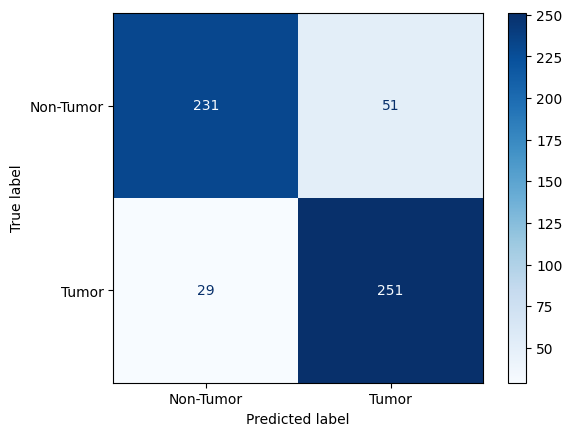

Thông tin cấu hình MobileNetV4:
- Dung lượng file trọng số (.pth): 37.88 MB
- Tham số ước tính: 9794929


In [ ]:
# @title
# Load pretrained model
model = timm.create_model(
    # 'mobilenetv4_hybrid_medium.e200_r256_in12k_ft_in1k',
    'mobilenetv4_hybrid_medium.ix_e550_r384_in1k',
    pretrained=True
)

# Thay classifier cho binary classification
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 1)

model = model.to(device)

# 1. Tải trọng số mô hình tốt nhất (Best Model)
best_model_path = '/content/best_mobilenetv4.pth'
model.load_state_dict(torch.load(best_model_path))
model.eval()

# 2. Dự đoán trên tập Val/Test
all_preds = []
all_labels = []

print("Bắt đầu đánh giá trên tập Test...")
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        # Áp dụng sigmoid để đưa output về dải [0, 1]
        probs = torch.sigmoid(outputs)

        # Threshold 0.5 cho phân loại nhị phân
        preds = (probs > 0.3).float()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Tính toán các Metrics (Top-1 Acc, Precision, Recall, F1)
y_true = np.array(all_labels).flatten()
y_pred = np.array(all_preds).flatten()

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("-" * 30)
print(f"KẾT QUẢ ĐÁNH GIÁ (MobileNetV4):")
print(f"Top-1 Accuracy : {acc*100:.2f}%")
print(f"Precision      : {precision*100:.2f}%")
print(f"Recall         : {recall*100:.2f}%")
print(f"F1-score       : {f1*100:.2f}%")
print("-" * 30)

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Tumor", "Tumor"])
disp.plot(cmap='Blues')
plt.show()

# 4. In thông tin dung lượng file trọng số mô hình
model_size_bytes = os.path.getsize(best_model_path)
model_size_mb = model_size_bytes / (1024 * 1024)
total_params = sum(p.numel() for p in model.parameters())

print(f"Thông tin cấu hình MobileNetV4:")
print(f"- Dung lượng file trọng số (.pth): {model_size_mb:.2f} MB")
print(f"- Tham số ước tính: {total_params}")

Bắt đầu đánh giá trên tập Test theo tiêu chuẩn Y tế...
--------------------------------------------------
KẾT QUẢ ĐÁNH GIÁ Y KHOA (MOBILENETV4):
AUC-ROC Score                  : 0.9514
Sensitivity (Độ nhạy)          : 89.64%  (Khả năng phát hiện BỆNH)
Specificity (Độ đặc hiệu)      : 81.91%  (Khả năng loại trừ KHÔNG BỆNH)
PPV (Giá trị dự báo Dương tính): 83.11%
NPV (Giá trị dự báo Âm tính)   : 88.85%
--------------------------------------------------


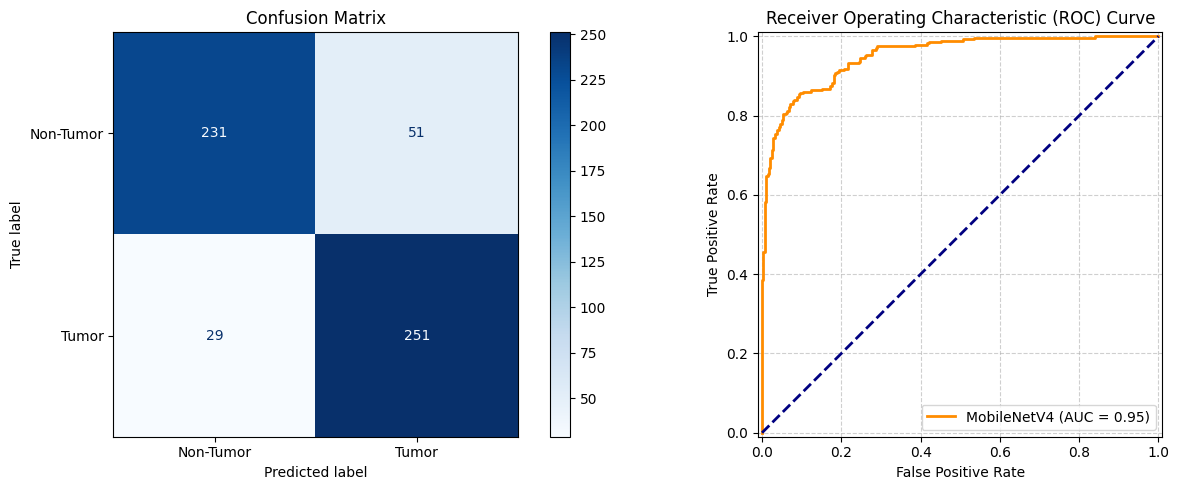


Thông tin cấu hình MobileNetV4:
- Dung lượng file trọng số (.pth): 37.88 MB
- Tham số ước tính: 9,794,929


In [ ]:
# @title
import numpy as np
import torch
import os
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay
)

# --- KHỞI TẠO MÔ HÌNH (Giữ nguyên logic của bạn) ---
model = timm.create_model('mobilenetv4_hybrid_medium.ix_e550_r384_in1k', pretrained=True)
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 1)
model = model.to(device)

# 1. Tải trọng số mô hình tốt nhất (Best Model)
best_model_path = '/content/best_mobilenetv4.pth'
model.load_state_dict(torch.load(best_model_path))
model.eval()

# 2. Dự đoán trên tập Val/Test
all_probs = []   # Thêm danh sách lưu xác suất (phục vụ tính AUC/ROC)
all_preds = []
all_labels = []

print("Bắt đầu đánh giá trên tập Test theo tiêu chuẩn Y tế...")
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        # Áp dụng sigmoid để đưa output về dải [0, 1] (Xác suất mắc bệnh)
        probs = torch.sigmoid(outputs)

        # Ngưỡng phân loại mặc định (Threshold = 0.5)
        preds = (probs > 0.3).float()

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Chuyển đổi sang dạng mảng phẳng (Flatten)
y_true = np.array(all_labels).flatten()
y_pred = np.array(all_preds).flatten()
y_prob = np.array(all_probs).flatten()

# 3. Tính toán Ma trận nhầm lẫn (Confusion Matrix) trước để lấy các chỉ số y tế
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# --- TÍNH TOÁN CÁC CHỈ SỐ Y TẾ ---
# Sensitivity (Độ nhạy) = TP / (TP + FN) -> Chính là Recall
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

# Specificity (Độ đặc hiệu) = TN / (TN + FP)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

# PPV (Giá trị dự báo dương tính) = TP / (TP + FP) -> Chính là Precision
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0

# NPV (Giá trị dự báo âm tính) = TN / (TN + FN)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

# AUC-ROC Score
auc_score = roc_auc_score(y_true, y_prob)

# --- IN KẾT QUẢ ĐÁNH GIÁ CHI TIẾT ---
print("-" * 50)
print(f"KẾT QUẢ ĐÁNH GIÁ Y KHOA (MOBILENETV4):")
print(f"AUC-ROC Score                  : {auc_score:.4f}")
print(f"Sensitivity (Độ nhạy)          : {sensitivity*100:.2f}%  (Khả năng phát hiện BỆNH)")
print(f"Specificity (Độ đặc hiệu)      : {specificity*100:.2f}%  (Khả năng loại trừ KHÔNG BỆNH)")
print(f"PPV (Giá trị dự báo Dương tính): {ppv*100:.2f}%")
print(f"NPV (Giá trị dự báo Âm tính)   : {npv*100:.2f}%")
print("-" * 50)

# 4. TRỰC QUAN HÓA ĐỒ THỊ (Confusion Matrix & ROC Curve)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Đồ thị 1: Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Tumor", "Tumor"])
disp.plot(cmap='Blues', ax=ax[0])
ax[0].set_title("Confusion Matrix")

# Đồ thị 2: ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_score, estimator_name='MobileNetV4')
roc_disp.plot(ax=ax[1], color='darkorange', lw=2)
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Đường vô thưởng vô phạt (Random guess)
ax[1].set_title("Receiver Operating Characteristic (ROC) Curve")
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 5. In thông tin dung lượng file trọng số mô hình (Giữ nguyên)
model_size_bytes = os.path.getsize(best_model_path)
model_size_mb = model_size_bytes / (1024 * 1024)
total_params = sum(p.numel() for p in model.parameters())

print(f"\nThông tin cấu hình MobileNetV4:")
print(f"- Dung lượng file trọng số (.pth): {model_size_mb:.2f} MB")
print(f"- Tham số ước tính: {total_params:,}")

In [ ]:
# ── Lưu ảnh tổng hợp 3 panel cho báo cáo ────────────────────────────
# Chạy cell này SAU cell Test (y_true, y_pred, y_prob đã có)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Panel (a): Confusion Matrix
ax1 = fig.add_subplot(gs[0])
cm_mat = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm_mat, display_labels=['Bình thường', 'Có bệnh'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('(a) Ma trận nhầm lẫn\n(Confusion Matrix)', fontsize=12, fontweight='bold')

# Panel (b): ROC Curve
ax2 = fig.add_subplot(gs[1])
fpr_v, tpr_v, _ = roc_curve(y_true, y_prob)
roc_auc_v = auc(fpr_v, tpr_v)
ax2.plot(fpr_v, tpr_v, color='darkorange', lw=2, label=f'AUC = {roc_auc_v:.4f}')
ax2.plot([0,1],[0,1], 'k--', lw=1)
ax2.fill_between(fpr_v, tpr_v, alpha=0.08, color='darkorange')
ax2.set_xlim([0,1]); ax2.set_ylim([0,1.02])
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate', fontsize=11)
ax2.set_title(f'(b) Đường cong ROC\n(AUC = {roc_auc_v:.4f})', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=11)

# Panel (c): Phân phối xác suất
ax3 = fig.add_subplot(gs[2])
ax3.hist(y_prob[y_true==0], bins=30, alpha=0.6, color='steelblue', label='Bình thường', density=True)
ax3.hist(y_prob[y_true==1], bins=30, alpha=0.6, color='tomato',    label='Có bệnh',    density=True)
ax3.axvline(0.5, color='black', ls='--', lw=1.5, label='Ngưỡng=0.5')
ax3.set_xlabel('Xác suất dự đoán', fontsize=11)
ax3.set_ylabel('Mật độ', fontsize=11)
ax3.set_title('(c) Phân phối xác suất\ndự đoán', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)

plt.suptitle('Đánh giá MobileNetV4 Gatekeeper — Tập kiểm thử (N=562)',
             fontsize=13, fontweight='bold', y=1.02)

save_path = 'classification_evaluation.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'✅ Đã lưu: {save_path}')
print(f'   → Copy vào: Report/images/classification_evaluation.png')

# Download về máy (Colab)
try:
    from google.colab import files
    files.download(save_path)
except ImportError:
    pass  # Kaggle: tải từ Files panel bên phải

### **Download checkpoint**

In [ ]:
from google.colab import files
files.download('/content/checkpoint/best_mobilenetv4.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>